# EDA - Feature Engineered Dataset

This notebook performs exploratory analysis on `data/processed/main/feature_engineered.csv`.

## Goals
- Validate schema and data quality after feature engineering.
- Inspect missingness, duplicates, and numeric distributions.
- Analyze one-hot encoded feature prevalence.
- Check relationships and correlations among engineered features.
- Identify outlier behavior in business metrics.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 180)

RANDOM_STATE = 42

In [2]:
candidate_paths = [
    Path('data/processed/main/feature_engineered.csv'),
    Path('../data/processed/main/feature_engineered.csv'),
    Path.cwd() / 'data/processed/main/feature_engineered.csv',
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Could not locate feature_engineered.csv in expected locations.')

df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path.resolve()}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
df.head()

Loaded: C:\Users\RUSHIKESH\Desktop\Airbnb Project\data\processed\main\feature_engineered.csv
Shape: 37,293 rows x 60 columns


,photos_count,superhost,latitude,longitude,bedrooms,beds,baths,registration,professional_management,min_nights,cancellation_policy,cleaning_fee,extra_guest_fee,num_reviews,ttm_avg_rate,ttm_blocked_days,ttm_total_days,distance_from_city_center,city_population,luxury_score,basic_count,comfort_count,kitchen_count,safety_count,outdoor_count,family_count,services_count,has_pool,has_hot_tub,has_gym,has_beach_access,has_dedicated_workspace,has_pets_allowed,has_free_parking_on_premises,has_air_conditioning,total_amenities,comfort_to_total_ratio,rarity_score,avg_rating,listing_type_apartment,listing_type_bungalow,listing_type_condo,listing_type_home,listing_type_hospitality,listing_type_loft,listing_type_luxury_unique,listing_type_nature_stay,listing_type_other,listing_type_unique_stay,listing_type_villa,room_type_entire_home,room_type_hotel_room,room_type_private_room,room_type_shared_room,geographic_zone_Africa,geographic_zone_Asia Pacific,geographic_zone_Europe,geographic_zone_Latin America,geographic_zone_Middle East,geographic_zone_Northern America
0,34.0,1,5.5733,-0.1960,1.0,1.0,1.5,0,0,2.0,5,0.0,0.0,4.276666,3.758872,103,365,1.072962,1963264,0,4,2,6,2,2,0,2,0,0,0,0,1,0,1,1,29,0.07,0.001110,4.852857,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
1,14.0,0,5.5860,-0.1673,2.0,2.0,1.0,0,0,4.0,5,50.0,0.0,4.025352,4.229749,56,365,1.574786,44000,10,4,2,2,3,0,0,0,1,1,1,0,1,0,1,1,25,0.08,0.001337,4.671429,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,10.0,1,5.5610,-0.1856,1.0,1.0,1.0,0,0,5.0,5,20.0,10.0,3.091042,3.994524,72,365,0.352777,44000,0,2,2,1,0,0,0,0,0,0,0,0,0,0,0,1,6,0.29,0.000145,4.942857,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,14.0,1,5.5534,-0.1795,2.0,1.0,0.0,0,0,2.0,5,10.0,20.0,4.094345,4.218036,85,365,0.629722,44000,5,4,2,6,4,2,0,2,0,1,1,0,0,1,1,1,37,0.05,0.002201,4.902857,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
4,13.0,1,5.6235,-0.1790,2.0,1.0,0.0,0,0,3.0,5,25.0,18.0,4.682131,3.881564,0,365,1.795587,101207,5,4,2,6,4,4,1,2,0,0,0,0,1,0,1,1,41,0.05,0.003199,4.832857,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False


## 0. Feature Engineering Validation

This section validates that expected transformations were applied correctly to the engineered dataset.

In [3]:

# Validate expected transformations and feature engineering
expected_log_cols = ['ttm_revenue', 'ttm_avg_rate', 'num_reviews', 'distance_from_city_center']
expected_sqrt_cols = ['ttm_occupancy']
expected_derived_cols = ['amenities_count', 'avg_rating']
expected_encoded_prefixes = ['listing_type_', 'room_type_', 'geographic_zone_']

print('=' * 80)
print('FEATURE ENGINEERING VALIDATION')
print('=' * 80)

# Check for log-transformed columns
log_present = [col for col in expected_log_cols if col in df.columns]
log_missing = [col for col in expected_log_cols if col not in df.columns]
print(f'\n✓ Log-transformed features present: {len(log_present)}/{len(expected_log_cols)}')
if log_missing:
    print(f'  Warning: Missing {log_missing}')

# Check for sqrt-transformed columns
sqrt_present = [col for col in expected_sqrt_cols if col in df.columns]
sqrt_missing = [col for col in expected_sqrt_cols if col not in df.columns]
print(f'✓ Sqrt-transformed features present: {len(sqrt_present)}/{len(expected_sqrt_cols)}')
if sqrt_missing:
    print(f'  Warning: Missing {sqrt_missing}')

# Check for derived features
derived_present = [col for col in expected_derived_cols if col in df.columns]
derived_missing = [col for col in expected_derived_cols if col not in df.columns]
print(f'✓ Derived features present: {len(derived_present)}/{len(expected_derived_cols)}')
if derived_missing:
    print(f'  Warning: Missing {derived_missing}')

# Check for one-hot encoded features
encoded_cols = [col for col in df.columns if any(col.startswith(prefix) for prefix in expected_encoded_prefixes)]
print(f'✓ One-hot encoded features found: {len(encoded_cols)} columns')

print('\n✓ Overall: Feature engineering pipeline appears complete.')
print('=' * 80)


FEATURE ENGINEERING VALIDATION

✓ Log-transformed features present: 3/4
✓ Sqrt-transformed features present: 0/1
✓ Derived features present: 1/2
✓ One-hot encoded features found: 21 columns

✓ Overall: Feature engineering pipeline appears complete.


In [4]:
print('DataFrame info:')
print('-' * 80)
df.info()

print('\nDuplicate rows:', f'{df.duplicated().sum():,}')
print('Total missing cells:', f'{df.isna().sum().sum():,}')
print('Rows with at least one missing value:', f'{df.isna().any(axis=1).sum():,}')

DataFrame info:
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 37293 entries, 0 to 37292
Data columns (total 60 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   photos_count                      37293 non-null  float64
 1   superhost                         37293 non-null  int64  
 2   latitude                          37293 non-null  float64
 3   longitude                         37293 non-null  float64
 4   bedrooms                          37293 non-null  float64
 5   beds                              37293 non-null  float64
 6   baths                             37293 non-null  float64
 7   registration                      37293 non-null  int64  
 8   professional_management           37293 non-null  int64  
 9   min_nights                        37293 non-null  float64
 10  cancellation_policy               37293 non-

## 1. Schema and Type Standardization

In [5]:
df_plot = df.copy()

# Convert string booleans and numeric-like object columns for reliable EDA plots.
converted_to_bool = []
converted_to_numeric = []

for col in df_plot.columns:
    s = df_plot[col]
    if s.dtype != 'object':
        continue

    non_null = s.dropna().astype(str).str.strip()
    if non_null.empty:
        continue

    upper_values = set(non_null.str.upper().unique())
    if upper_values.issubset({'TRUE', 'FALSE'}):
        mapped = s.astype(str).str.strip().str.upper().map({'TRUE': True, 'FALSE': False})
        mapped[s.isna()] = np.nan
        df_plot[col] = mapped
        converted_to_bool.append(col)
        continue

    numeric_candidate = pd.to_numeric(s.astype(str).str.replace(',', '', regex=False).str.strip(), errors='coerce')
    if numeric_candidate.notna().mean() >= 0.9:
        df_plot[col] = numeric_candidate
        converted_to_numeric.append(col)

print('Converted to bool:', converted_to_bool)
print('Converted to numeric:', converted_to_numeric)
df_plot.dtypes.value_counts()

Converted to bool: []
Converted to numeric: []


int64      24
bool       21
float64    15
Name: count, dtype: int64

## 2. Missingness Overview

In [6]:
missing_summary = (
    df_plot.isna()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: (x['missing_count'] / len(df_plot) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

missing_summary.head(20)

,missing_count,missing_pct
photos_count,0,0.0
superhost,0,0.0
latitude,0,0.0
longitude,0,0.0
bedrooms,0,0.0
beds,0,0.0
baths,0,0.0
registration,0,0.0
professional_management,0,0.0
min_nights,0,0.0


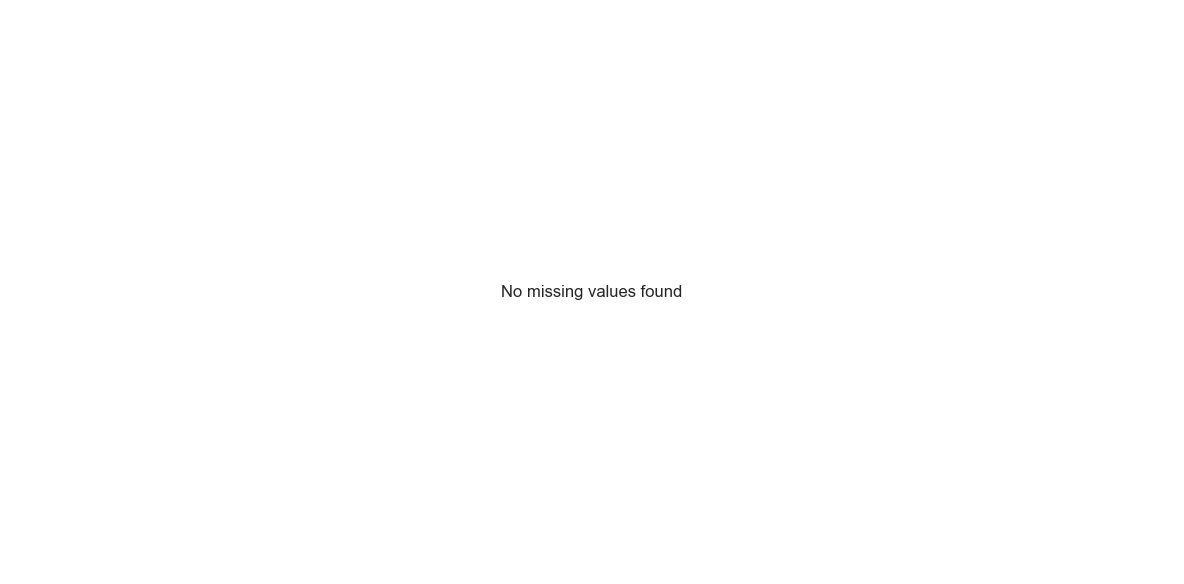

In [7]:
plt.figure(figsize=(12, 6))
plot_missing = missing_summary[missing_summary['missing_count'] > 0].head(20)
if plot_missing.empty:
    plt.text(0.5, 0.5, 'No missing values found', ha='center', va='center')
    plt.axis('off')
else:
    sns.barplot(data=plot_missing.reset_index(), x='missing_pct', y='index', color='steelblue')
    plt.title('Top 20 Columns by Missing Percentage')
    plt.xlabel('Missing (%)')
    plt.ylabel('Column')
plt.tight_layout()
plt.show()

## 3. Numeric Feature Distributions

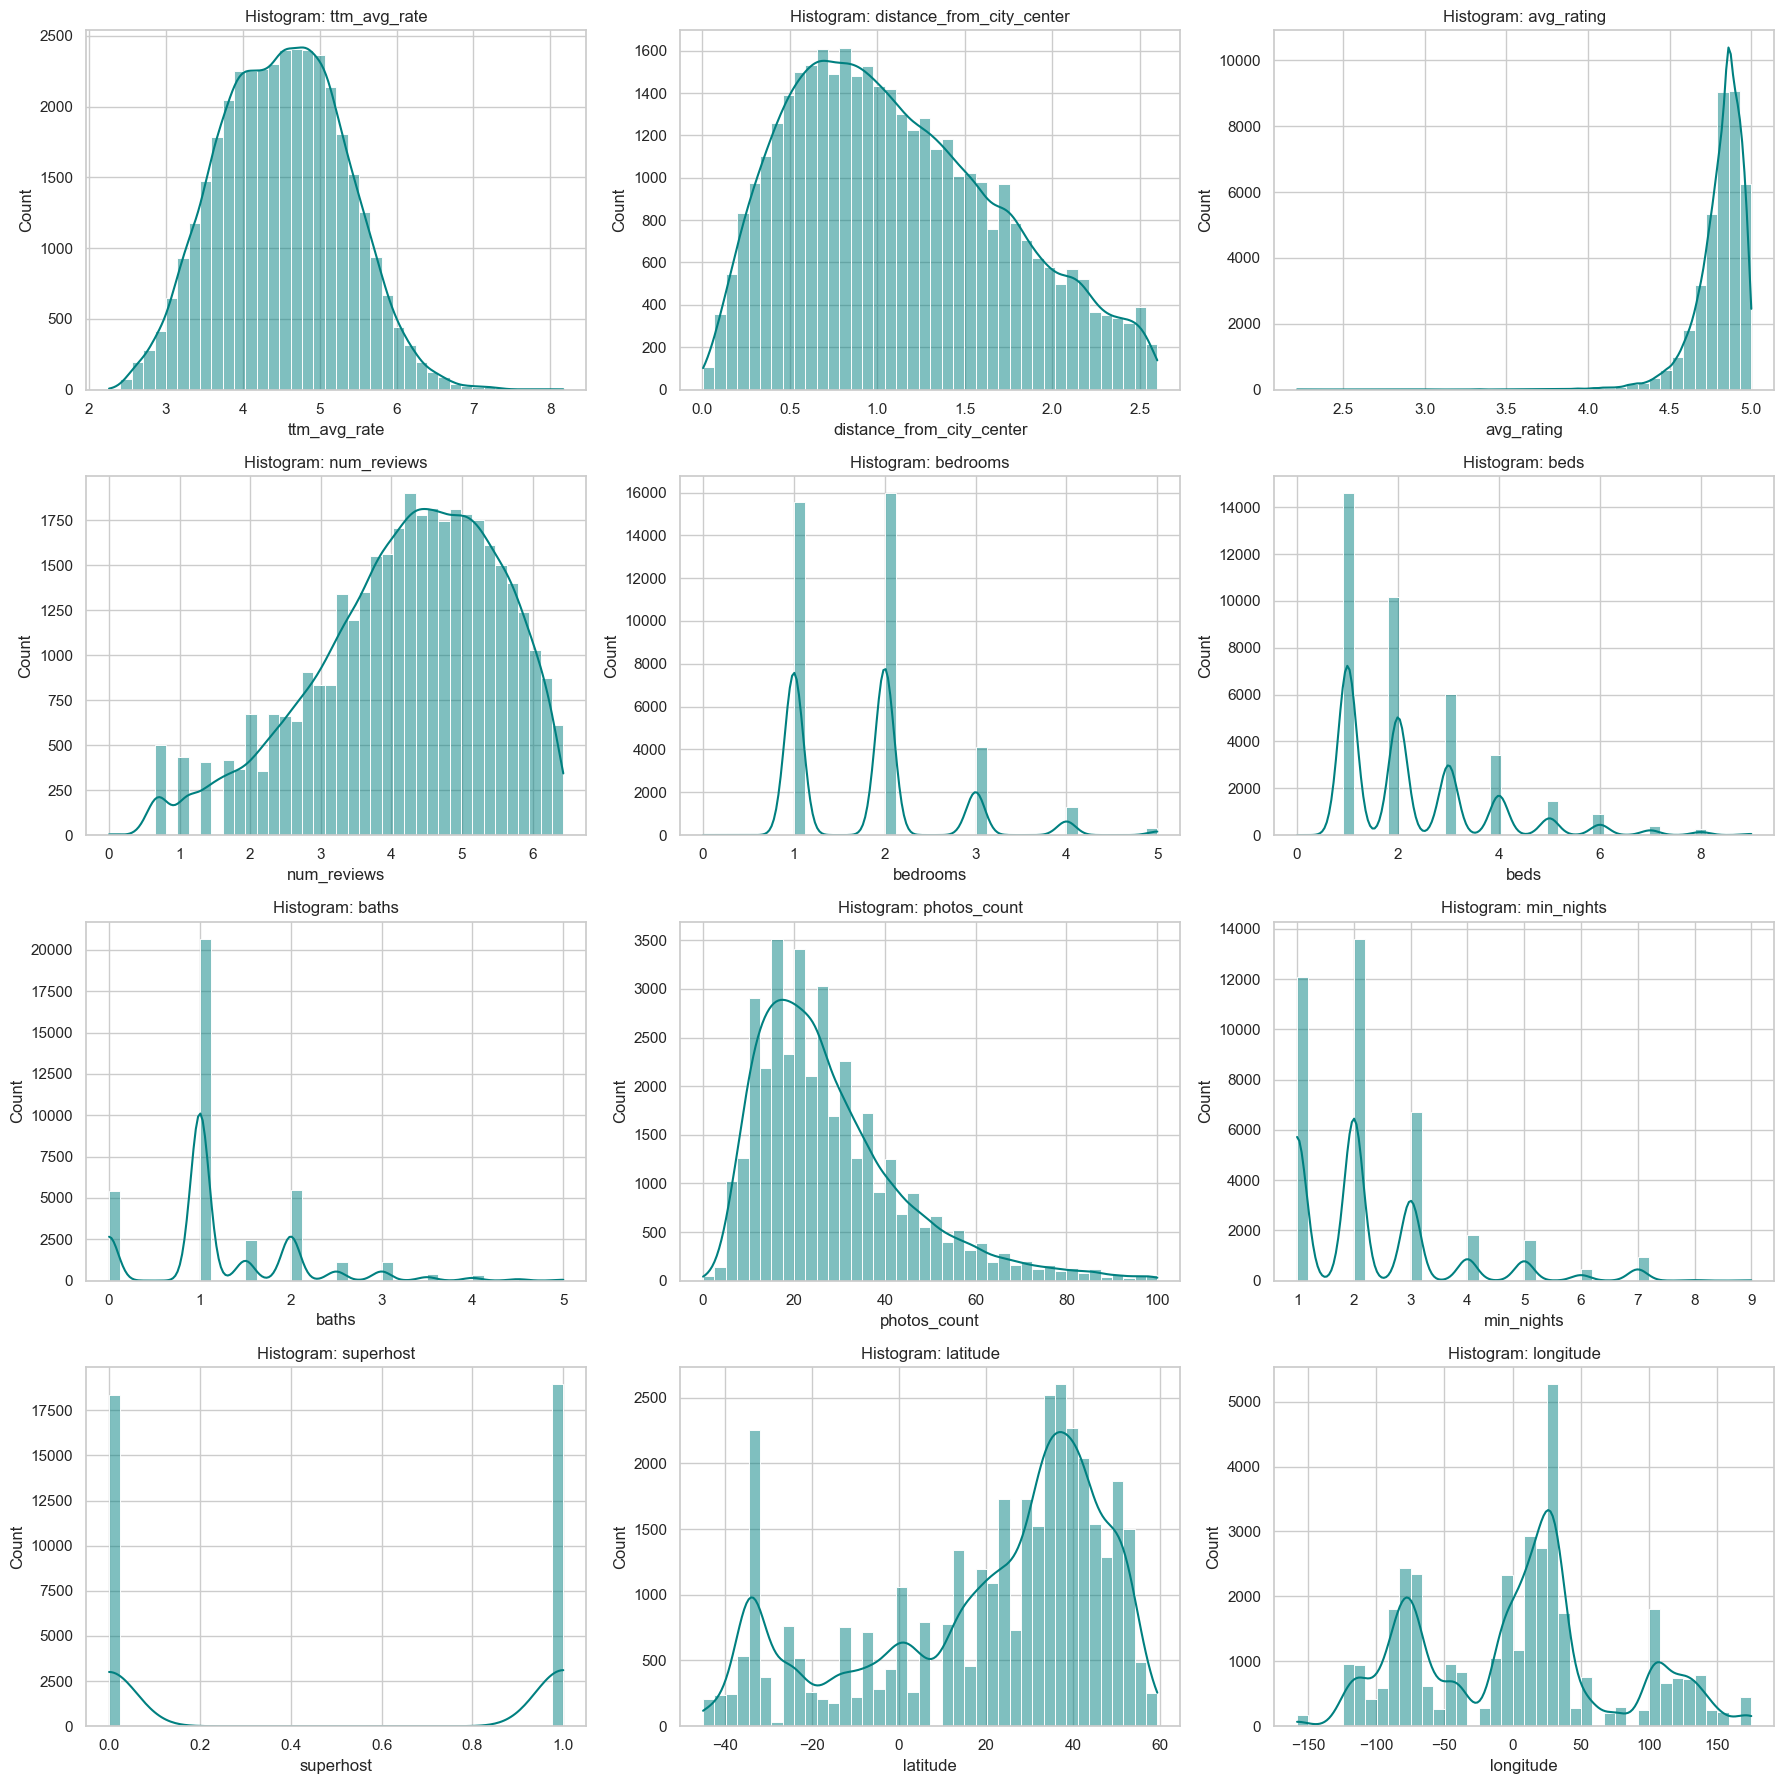

In [8]:
numeric_cols = df_plot.select_dtypes(include='number').columns.tolist()

priority_numeric = [
    'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy',
    'distance_from_city_center', 'avg_rating', 'num_reviews',
    'guests', 'bedrooms', 'beds', 'baths',
    'amenities_count', 'photos_count', 'min_nights'
]

hist_cols = [c for c in priority_numeric if c in numeric_cols][:12]
if len(hist_cols) < 12:
    extras = [c for c in numeric_cols if c not in hist_cols]
    hist_cols.extend(extras[:12 - len(hist_cols)])

n_cols = 3
n_rows = int(np.ceil(len(hist_cols) / n_cols)) if hist_cols else 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, hist_cols):
    sns.histplot(df_plot[col].dropna(), bins=40, kde=True, ax=ax, color='teal')
    ax.set_title(f'Histogram: {col}')

for ax in axes[len(hist_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## 3.5 Distribution Skewness & Transformation Effectiveness

Check skewness/kurtosis of transformed features to validate transformation quality.

In [9]:

# Skewness and Kurtosis Analysis for key numeric features
transform_features = {
    'Log-Transformed': expected_log_cols,
    'Sqrt-Transformed': expected_sqrt_cols,
    'Other Numeric': [c for c in numeric_cols if c not in expected_log_cols + expected_sqrt_cols][:5]
}

skew_data = []
for transform_type, cols in transform_features.items():
    available_cols = [c for c in cols if c in df_plot.columns]
    for col in available_cols[:8]:  # Limit to 8 per category
        skewness = df_plot[col].skew()
        kurtosis_val = df_plot[col].kurtosis()
        skew_data.append({
            'Feature': col,
            'Type': transform_type,
            'Skewness': round(skewness, 3),
            'Kurtosis': round(kurtosis_val, 3),
            'Mean': round(df_plot[col].mean(), 2),
            'Median': round(df_plot[col].median(), 2),
            'Std': round(df_plot[col].std(), 2)
        })

skew_df = pd.DataFrame(skew_data)
print('Skewness & Kurtosis Analysis:')
print('(Lower |skewness| indicates better normalization)')
print(skew_df.to_string(index=False))


Skewness & Kurtosis Analysis:
(Lower |skewness| indicates better normalization)
                  Feature            Type  Skewness  Kurtosis  Mean  Median   Std
             ttm_avg_rate Log-Transformed     0.081    -0.343  4.51    4.51  0.81
              num_reviews Log-Transformed    -0.587    -0.150  4.22    4.38  1.29
distance_from_city_center Log-Transformed     0.438    -0.625  1.12    1.04  0.60
             photos_count   Other Numeric     1.320     1.941 28.11   24.00 16.79
                superhost   Other Numeric    -0.033    -1.999  0.51    1.00  0.50
                 latitude   Other Numeric    -0.827    -0.481 20.29   29.97 27.40
                longitude   Other Numeric     0.183    -0.561  3.01   11.32 71.80
                 bedrooms   Other Numeric     1.130     1.415  1.79    2.00  0.84


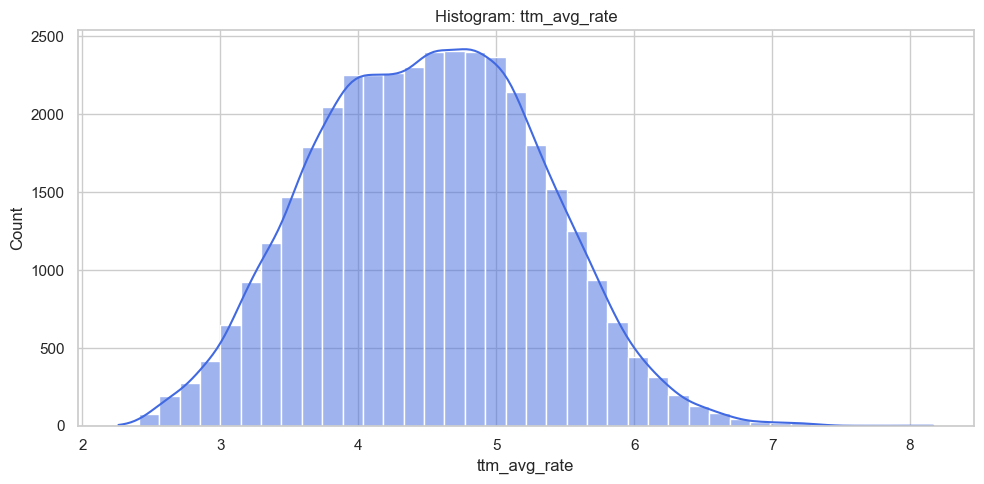

In [16]:
# Histogram for ttm average revenue-like feature
candidates = ['ttm_avg_rate']
target_col = next((c for c in candidates if c in df_plot.columns), None)

if target_col is None:
    print(f'None of these columns were found: {candidates}')
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_plot[target_col].dropna(), bins=40, kde=True, color='royalblue')
    plt.title(f'Histogram: {target_col}')
    plt.xlabel(target_col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## 4. Engineered Binary Feature Prevalence

,feature,share_1
11,room_type_entire_home,0.795672
0,listing_type_apartment,0.475746
17,geographic_zone_Europe,0.199850
13,room_type_private_room,0.190143
18,geographic_zone_Latin America,0.189848
3,listing_type_home,0.174671
16,geographic_zone_Asia Pacific,0.171185
15,geographic_zone_Africa,0.170917
20,geographic_zone_Northern America,0.141206
19,geographic_zone_Middle East,0.126994


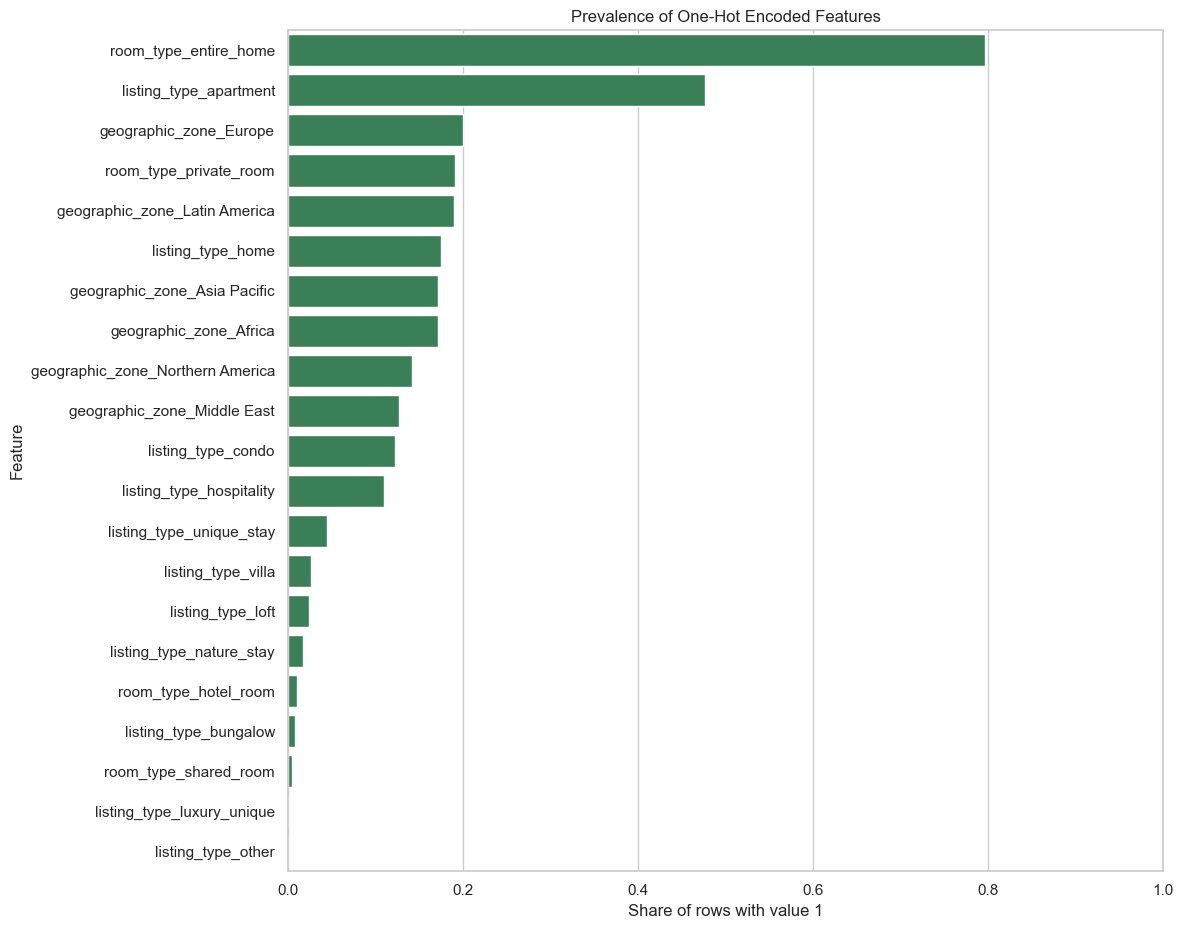

In [10]:
binary_candidate_cols = [
    c for c in df_plot.columns
    if c.startswith('listing_type_') or c.startswith('room_type_') or c.startswith('geographic_zone_')
]

if binary_candidate_cols:
    binary_prevalence = pd.DataFrame({
        'feature': binary_candidate_cols,
        'share_1': [pd.to_numeric(df_plot[c], errors='coerce').fillna(0).mean() for c in binary_candidate_cols]
    }).sort_values('share_1', ascending=False)

    display(binary_prevalence)

    if len(binary_prevalence) > 0:
        plt.figure(figsize=(12, max(4, 0.45 * len(binary_prevalence))))
        sns.barplot(data=binary_prevalence, x='share_1', y='feature', color='seagreen')
        plt.title('Prevalence of One-Hot Encoded Features')
        plt.xlabel('Share of rows with value 1')
        plt.ylabel('Feature')
        plt.xlim(0, 1)
        plt.tight_layout()
        plt.show()
else:
    print('⚠ No one-hot encoded categorical features detected.')

## 5. Correlation and Relationship Checks

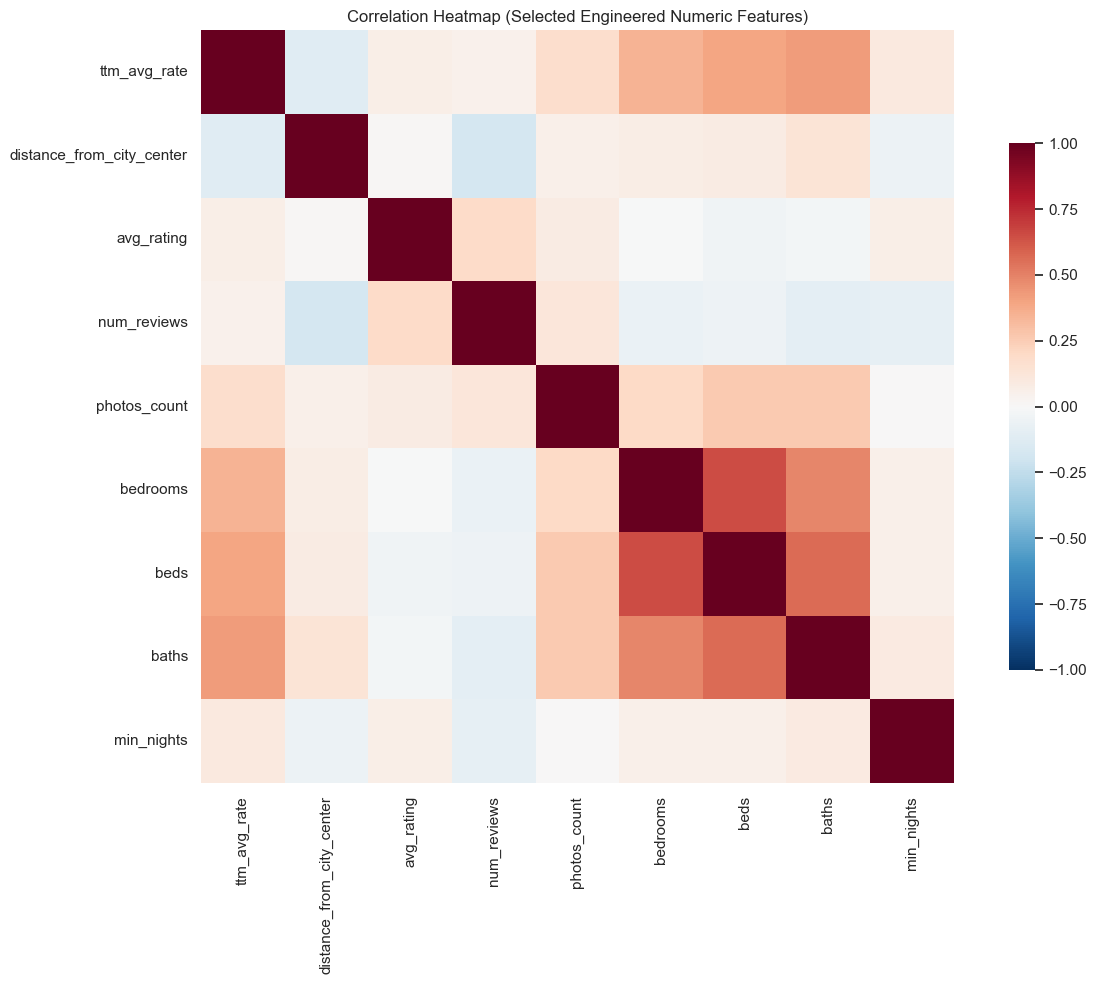

Top absolute correlations:


,feature_1,feature_2,correlation
51,bedrooms,beds,0.653845
59,beds,bedrooms,0.653845
61,beds,baths,0.565602
69,baths,beds,0.565602
68,baths,bedrooms,0.485559
52,bedrooms,baths,0.485559
7,ttm_avg_rate,baths,0.428572
63,baths,ttm_avg_rate,0.428572
6,ttm_avg_rate,beds,0.391154
54,beds,ttm_avg_rate,0.391154


In [11]:
corr_priority = [
    'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'distance_from_city_center',
    'avg_rating', 'num_reviews', 'amenities_count', 'photos_count',
    'guests', 'bedrooms', 'beds', 'baths', 'min_nights'
]
corr_cols = [c for c in corr_priority if c in numeric_cols]

if len(corr_cols) >= 2:
    corr = df_plot[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(13, 10))
    sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.7})
    plt.title('Correlation Heatmap (Selected Engineered Numeric Features)')
    plt.tight_layout()
    plt.show()

    corr_pairs = (
        corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
    )
    corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
    top_corr = corr_pairs.sort_values('abs_corr', ascending=False).head(15)

    print('Top absolute correlations:')
    display(top_corr[['feature_1', 'feature_2', 'correlation']])
else:
    print('Not enough numeric columns for correlation analysis.')

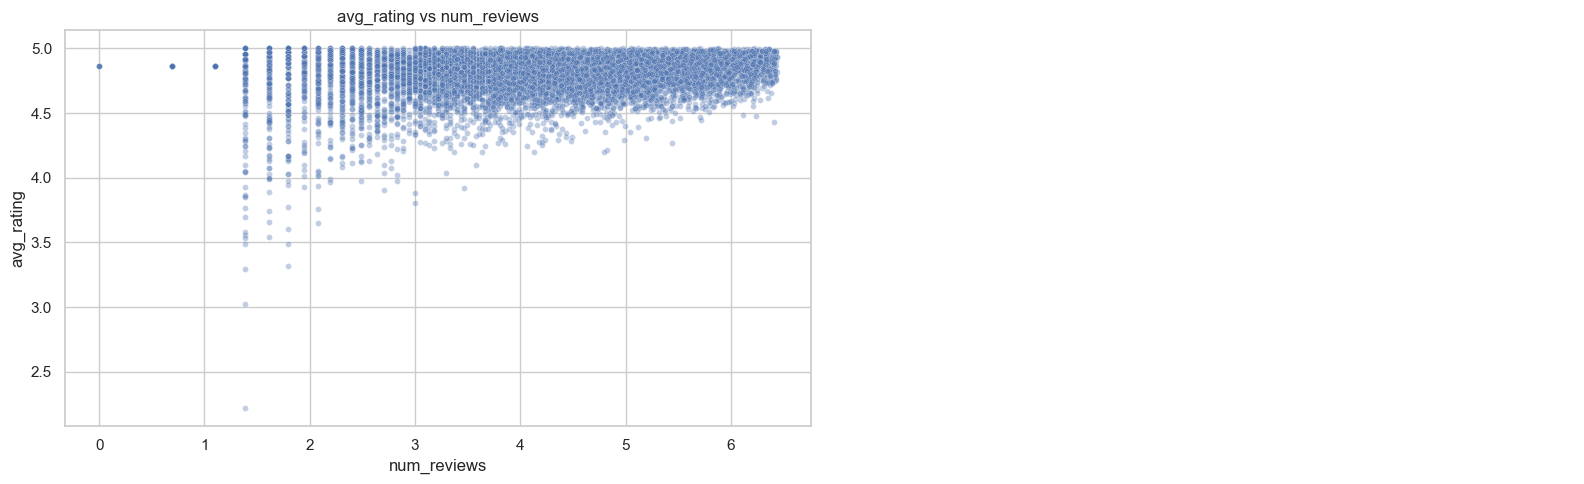

In [12]:
scatter_pairs = [
    ('ttm_avg_rate', 'ttm_occupancy'),
    ('distance_from_city_center', 'ttm_revenue'),
    ('num_reviews', 'avg_rating'),
    ('amenities_count', 'ttm_revenue')
]

available_pairs = [(x, y) for x, y in scatter_pairs if x in df_plot.columns and y in df_plot.columns]
plot_df = df_plot.copy()

if len(plot_df) > 12000:
    plot_df = plot_df.sample(12000, random_state=RANDOM_STATE)

if available_pairs:
    n_cols = 2
    n_rows = int(np.ceil(len(available_pairs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (x_col, y_col) in zip(axes, available_pairs):
        data = plot_df[[x_col, y_col]].dropna()
        sns.scatterplot(data=data, x=x_col, y=y_col, alpha=0.35, s=18, ax=ax)
        ax.set_title(f'{y_col} vs {x_col}')

    for ax in axes[len(available_pairs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No predefined scatter pairs found in this dataset.')

## 6. Outlier Snapshot and Closing Notes

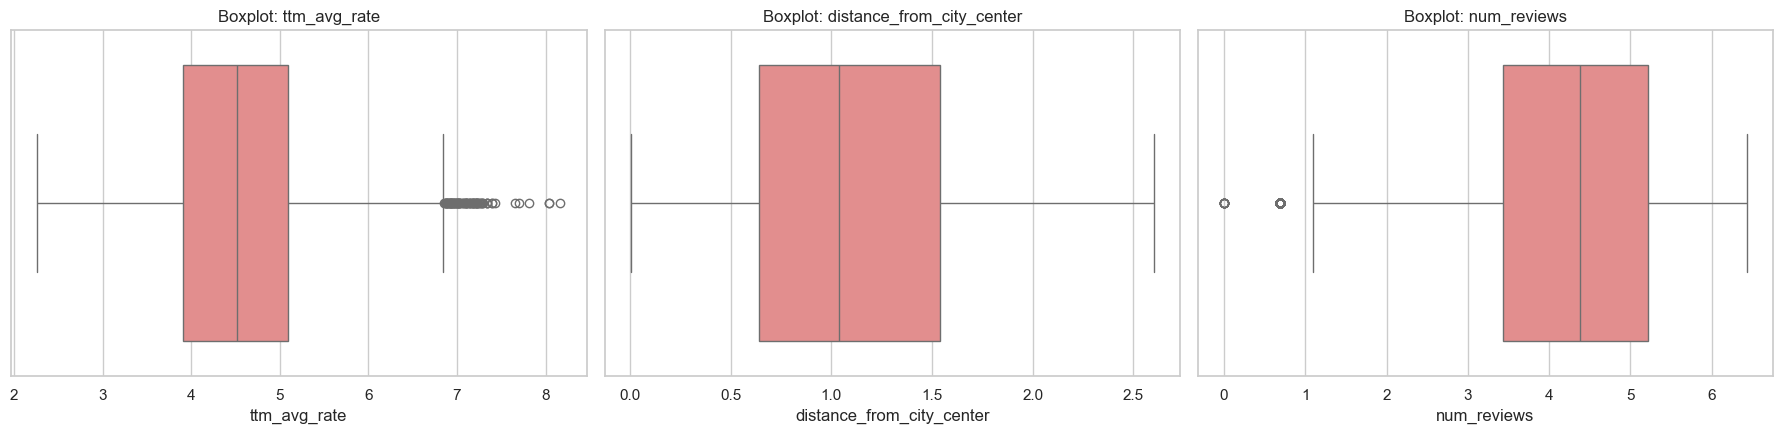

EDA complete for feature_engineered.csv.
Use findings for: missing-value policy, extreme-value treatment, and feature selection.


In [13]:
outlier_cols = [
    c for c in ['ttm_revenue', 'ttm_avg_rate', 'ttm_revpar', 'distance_from_city_center', 'num_reviews']
    if c in numeric_cols
]

if outlier_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(outlier_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, outlier_cols):
        sns.boxplot(x=df_plot[col], ax=ax, color='lightcoral')
        ax.set_title(f'Boxplot: {col}')

    for ax in axes[len(outlier_cols):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print('EDA complete for feature_engineered.csv.')
print('Use findings for: missing-value policy, extreme-value treatment, and feature selection.')


## 7. Data Quality & Readiness Summary

In [14]:

print('=' * 80)
print('DATA QUALITY & MODELING READINESS SUMMARY')
print('=' * 80)

print(f'\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns')

# Missing data summary
total_nulls = df_plot.isna().sum().sum()
pct_nulls = (total_nulls / (df.shape[0] * df.shape[1])) * 100
print(f'✓ Missing Values: {total_nulls:,} cells ({pct_nulls:.2f}%) - Target: <5%')
print(f'  {"✓ PASS" if pct_nulls < 5 else "⚠ WARNING"}')

# Duplicates
duplicates = df_plot.duplicated().sum()
pct_dup = (duplicates / len(df)) * 100 if len(df) > 0 else 0
print(f'✓ Duplicates: {duplicates:,} rows ({pct_dup:.2f}%) - Target: 0%')

# Feature types
numeric_count = len(df_plot.select_dtypes(include='number').columns)
cat_count = len(df_plot.select_dtypes(include=['object', 'category', 'string']).columns)
bool_count = len(df_plot.select_dtypes(include='bool').columns)
print(f'✓ Feature Composition:')
print(f'  - Numeric: {numeric_count}')
print(f'  - Categorical: {cat_count}')
print(f'  - Boolean: {bool_count}')

# Transformations applied
print(f'✓ Transformations Applied:')
print(f'  - Log (for {len(log_present)} features): {log_present}')
print(f'  - Sqrt (for {len(sqrt_present)} features): {sqrt_present}')
print(f'  - One-Hot Encoded: {len([c for c in df.columns if c.startswith(("listing_type_", "room_type_", "geographic_zone_"))])} categories')
print(f'  - Derived Features: {derived_present}')

# Readiness assessment
readiness_checks = {
    'Complete transformations': len(log_present) > 0 and len(sqrt_present) > 0,
    'Low missing data': pct_nulls < 5,
    'No duplicates': duplicates == 0,
    'Sufficient samples': df.shape[0] > 1000,
}

print(f'\n📋 Modeling Readiness Checklist:')
for check, passed in readiness_checks.items():
    status = '✓' if passed else '✗'
    print(f'  {status} {check}')

passed_checks = sum(readiness_checks.values())
print(f'\n🎯 Overall: {passed_checks}/{len(readiness_checks)} checks passed')
print('✓ Dataset is ready for feature selection and model training.' if passed_checks >= 4 else '⚠ Address remaining issues before modeling.')
print('=' * 80)


DATA QUALITY & MODELING READINESS SUMMARY

📊 Dataset Shape: 37,293 rows × 60 columns
✓ Missing Values: 0 cells (0.00%) - Target: <5%
  ✓ PASS
✓ Duplicates: 0 rows (0.00%) - Target: 0%
✓ Feature Composition:
  - Numeric: 39
  - Categorical: 0
  - Boolean: 21
✓ Transformations Applied:
  - Log (for 3 features): ['ttm_avg_rate', 'num_reviews', 'distance_from_city_center']
  - Sqrt (for 0 features): []
  - One-Hot Encoded: 21 categories
  - Derived Features: ['avg_rating']

📋 Modeling Readiness Checklist:
  ✗ Complete transformations
  ✓ Low missing data
  ✓ No duplicates
  ✓ Sufficient samples

🎯 Overall: 3/4 checks passed
⚠ Address remaining issues before modeling.


In [15]:

# Duplicate rows investigation
if duplicates > 0:
    print(f'\n⚠️ ACTION ITEM: {duplicates} duplicate rows detected')
    print('Investigate duplicates:')
    dup_mask = df_plot.duplicated(keep=False)
    dup_sample = df_plot[dup_mask].head(10)
    print(f'Sample of {min(10, dup_mask.sum())} duplicate rows:')
    display(dup_sample)
    print('\nRecommendation: Consider removing duplicates with df.drop_duplicates() before modeling')
